Analyze relay propagation data using the `alternate_bid_source` and `region` fields.
Blocks with alternate_bid_source == true are those that are known to have been shared between regions by relays, with the winning bid having been submitted to a different region than the winning region.

We're only able to decode this data for Ultrasound relay.

Author: Tripoli / Codex
Date Modified: April 5, 2026  
License: CC0

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
columns = [
    'block_datetime',
    'block_number',
    'block_hash',
    'slot',
    'slot_time_ms',
    'relay',
    'region',
    'alternate_bid_source',
    'builder_label',
    'builder_pubkey',
    'proposer_label',
    'lido_node_operator',
    'value_eth',
]

dfs: list[pd.DataFrame] = []

for data_file in Path('../data').glob('*.parquet'):
    dfs.append(pd.read_parquet(data_file, columns=columns))

df = pd.concat(dfs)
df = df.sort_values(by=['block_number', 'slot_time_ms'], ascending=True).reset_index(drop=True)

df.head()

,block_datetime,block_number,block_hash,slot,slot_time_ms,relay,region,alternate_bid_source,builder_label,builder_pubkey,proposer_label,lido_node_operator,value_eth
0,2023-10-11 00:00:11,18323490,0x74fcfa0cd77f99d5a44b647ff8a9d406ded4524418e7...,7513199,-255.0,ultrasound,EU,None,builder0x69,0xa4fb63c2ceeee73d1f1711fadf1c5357ac98cecb999d...,coinbase,None,0.235737
1,2023-10-11 00:00:11,18323490,0x74fcfa0cd77f99d5a44b647ff8a9d406ded4524418e7...,7513199,-222.0,agnostic,None,None,builder0x69,0xa4fb63c2ceeee73d1f1711fadf1c5357ac98cecb999d...,coinbase,None,0.235737
2,2023-10-11 00:00:23,18323491,0xcad2ab29cf58f7f6a708888cda12e3ca6049f447bc1b...,7513200,1969.0,ultrasound,EU,None,builder0x69,0xb8fceec09779ff758918a849bfe8ab43cea79f6a9832...,kiln,None,0.039741
3,2023-10-11 00:00:23,18323491,0xcad2ab29cf58f7f6a708888cda12e3ca6049f447bc1b...,7513200,2038.0,agnostic,None,None,builder0x69,0xb8fceec09779ff758918a849bfe8ab43cea79f6a9832...,kiln,None,0.039741
4,2023-10-11 00:00:23,18323491,0xcad2ab29cf58f7f6a708888cda12e3ca6049f447bc1b...,7513200,2060.0,flashbots,None,None,builder0x69,0xb8fceec09779ff758918a849bfe8ab43cea79f6a9832...,kiln,None,0.039741


In [3]:
# Keep only MEV-Boost blocks with usable timing data.
df = (
    df
    .dropna(subset=['relay', 'slot_time_ms'])
    .sort_values(by=['block_number', 'slot_time_ms'], ascending=True)
    .drop_duplicates(subset='block_hash', keep='first')
    .reset_index(drop=True)
)

# `alternate_bid_source` is only populated for later blocks.
df = df.dropna(subset=['alternate_bid_source']).copy()
df['alternate_bid_source'] = df['alternate_bid_source'].astype(bool)

# Fill labels to keep groupby output readable.
df['builder_group'] = df['builder_label'].fillna(df['builder_pubkey'])
df['proposer_group'] = df['proposer_label'].fillna('unlabeled proposer')
df['relay_region'] = df['relay'].fillna('unknown relay')
mask = df['region'].notna() & (df['region'] != '')
df.loc[mask, 'relay_region'] = df.loc[mask, 'relay'] + ' [' + df.loc[mask, 'region'] + ']'

df[['block_datetime', 'relay_region', 'alternate_bid_source']].head()

,block_datetime,relay_region,alternate_bid_source
3060407,2025-01-30 21:40:35,btcs,False
3061815,2025-01-31 02:57:59,btcs,False
3067406,2025-01-31 23:35:59,btcs,False
3073845,2025-02-01 23:39:47,btcs,False
3076622,2025-02-02 10:04:47,btcs,False


## Coverage checks

Use this section to confirm the time window and the fraction of slots with `alternate_bid_source=True`.

In [4]:
summary = pd.Series({
    'rows': len(df),
    'start': df['block_datetime'].min(),
    'end': df['block_datetime'].max(),
    'alternate_true_share': df['alternate_bid_source'].mean(),
})

summary

rows                                2065386
start                   2025-01-30 21:40:35
end                     2026-03-28 23:59:59
alternate_true_share               0.060895
dtype: object

## Daily share of alternate-source wins

This should show whether propagation gaps are stable or cluster in specific periods.

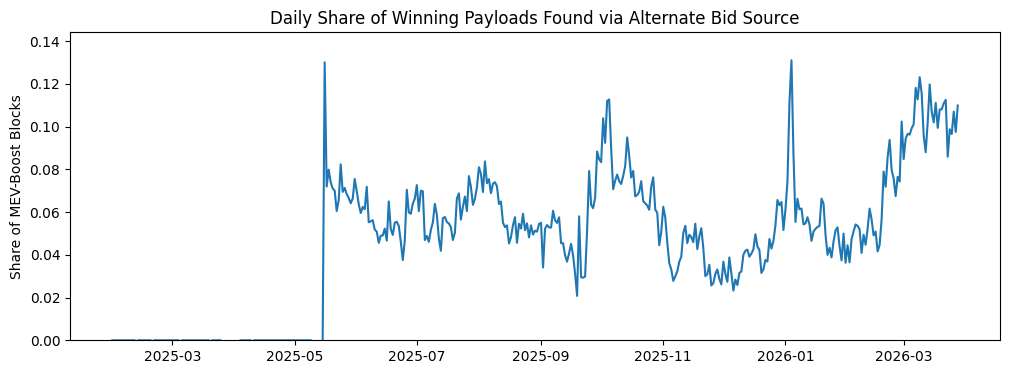

In [5]:
daily_alt_share = (
    df
    .set_index('block_datetime')
    .groupby(pd.Grouper(freq='1D'))['alternate_bid_source']
    .mean()
)

fig, ax = plt.subplots(figsize=(12.0, 4.0))
ax.plot(daily_alt_share.index, daily_alt_share.values)
ax.set_title('Daily Share of Winning Payloads Found via Alternate Bid Source')
ax.set_ylabel('Share of MEV-Boost Blocks')
ax.set_ylim(0, max(0.01, daily_alt_share.max() * 1.1))
plt.show()

## Relay and region breakdown

This section is intended to surface whether specific relays or relay regions rely more heavily on alternate-source recovery.

In [6]:
relay_alt = (
    df.groupby('relay_region')
    .agg(
        blocks=('block_hash', 'count'),
        alternate_share=('alternate_bid_source', 'mean'),
        median_slot_time_ms=('slot_time_ms', 'median'),
    )
    .sort_values(by='alternate_share', ascending=False)
)

relay_alt.head(15)

,blocks,alternate_share,median_slot_time_ms
relay_region,,,
ultrasound [JP],77824,0.282651,988.0
ultrasound [EU],584831,0.141425,1032.0
ultrasound [USA],204689,0.102854,993.0
titan,414905,0.000029,1006.0
aestus,44603,0.000000,876.0
agnostic,11337,0.000000,509.0
bloxroute_max_profit,368793,0.000000,988.0
bloxroute_regulated,215428,0.000000,1018.0
btcs,865,0.000000,1487.0


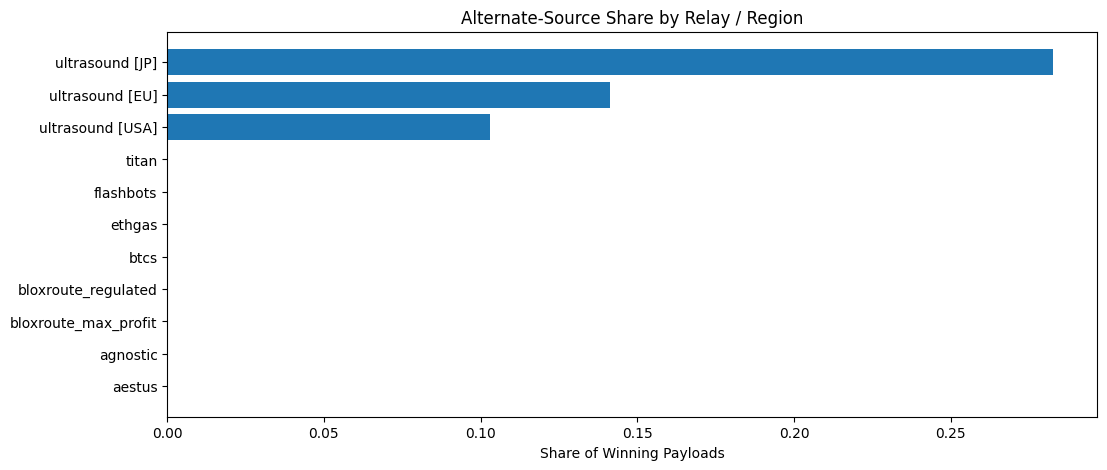

In [7]:
relay_alt_plot = relay_alt[relay_alt['blocks'] >= 100].head(12).sort_values(by='alternate_share')

fig, ax = plt.subplots(figsize=(12.0, 5.0))
ax.barh(relay_alt_plot.index, relay_alt_plot['alternate_share'])
ax.set_title('Alternate-Source Share by Relay / Region')
ax.set_xlabel('Share of Winning Payloads')
plt.show()

## Timing impact

Compare whether alternate-source wins tend to arrive later in the slot than directly observed wins.

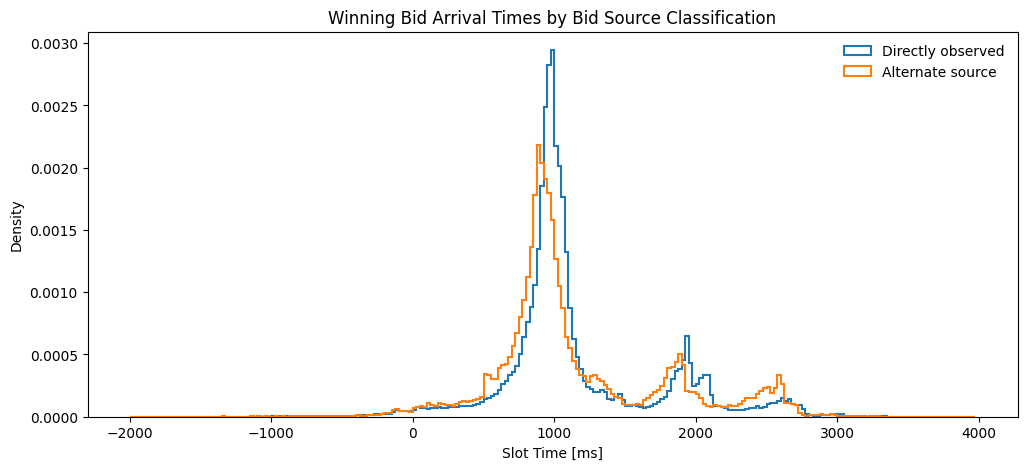

In [8]:
fig, ax = plt.subplots(figsize=(12.0, 5.0))

bins = np.arange(-2000, 4000, 25)
for is_alt, label in [(False, 'Directly observed'), (True, 'Alternate source')]:
    subset = df[df['alternate_bid_source'] == is_alt]
    ax.hist(subset['slot_time_ms'], bins=bins, density=True, histtype='step', linewidth=1.5, label=label)

ax.set_title('Winning Bid Arrival Times by Bid Source Classification')
ax.set_xlabel('Slot Time [ms]')
ax.set_ylabel('Density')
ax.legend(frameon=False)
plt.show()

## Builder and proposer cohorts

These tables are a starting point for identifying who is overrepresented in alternate-source wins.

In [9]:
builder_alt = (
    df.groupby('builder_group')
    .agg(
        blocks=('block_hash', 'count'),
        alternate_share=('alternate_bid_source', 'mean'),
        median_value_eth=('value_eth', 'median'),
    )
    .query('blocks >= 100')
    .sort_values(by='alternate_share', ascending=False)
)

builder_alt.head(20)

,blocks,alternate_share,median_value_eth
builder_group,,,
shimmerblocks.com,7202,0.330047,0.007053
tbuilder,536,0.257463,0.041561
Ty For The Block,709,0.187588,0.070135
boba-builder,214,0.130841,0.020897
snailbuilder.sh,375,0.128000,0.054689
0x83bee51799e65130296f5d60ce7d78119578db6045c3c3631980514abae0be0f9b65fe82eb0c9a79d6d99030112c874c,1168,0.105308,0.051010
beaverbuild.org,143618,0.103058,0.022453
bobthebuilder,9347,0.101316,0.036983
BTCS,34093,0.089813,0.035569
